In [1]:
%pip install astroquery

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from astroquery.sdss import SDSS
from scipy.ndimage import gaussian_filter, label

In [15]:
"""
QUERY: 
SELECT TOP 50000000
    p.ra, p.dec, s.z into mydb.FiftyMilGalaxies from SpecObj AS s
JOIN PhotoObj AS p ON s.bestobjiD = p.objid
WHERE s.class = 'GALAXY'
    AND s.z > 0.01 AND s.z < 0.1
    AND s.zWarning = 0

limited number of galaxies in sdss that have spectroscopically measured redshifts

maybe check where p.z class and stuff with p.z 
WHERE s.class = 'GALAXY'
    AND s.z > 0.01 AND s.z < 0.1
    AND s.zWarning = 0

SELECT TOP 50000000
    p.ra, p.dec, p.z into mydb.FiftyMilGalaxies from PhotoObj AS p
WHERE p.class = 'GALAXY'
    AND p.z > 0.01 AND p.z < 0.1

more warnings for photometric valued galxies but we still want to consider them
    
"""

df = pd.read_csv("new50mil_mikamustafayev24.csv")
ra, dec, z = df["ra"].values, df["dec"].values, df["z"].values

print(f"{len(df):,} SDSS galaxies")
print(f"RA  {ra.min():.2f}–{ra.max():.2f} deg | "
      f"Dec {dec.min():.2f}–{dec.max():.2f} deg | "
      f"z {z.min():.3f}–{z.max():.3f}")

2,589,258 SDSS galaxies
RA  0.00–360.00 deg | Dec -16.76–83.85 deg | z 0.010–1.000


In [16]:
df.columns

Index(['ra', 'dec', 'z'], dtype='object')

In [17]:
ra  = df['ra'].values
dec = df['dec'].values
z   = df['z'].values

sky_coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")

In [18]:
cosmo = FlatLambdaCDM(H0=67.66 * u.km / u.s / u.Mpc, Om0=0.31) #Planck-18

In [19]:
comoving_distance = cosmo.comoving_distance(z)


In [20]:
x_coord = comoving_distance * np.cos(sky_coords.dec.rad) * np.cos(sky_coords.ra.rad)
y_coord = comoving_distance * np.cos(sky_coords.dec.rad) * np.sin(sky_coords.ra.rad)
z_coord = comoving_distance * np.sin(sky_coords.dec.rad)

In [21]:
galaxy_positions = np.column_stack((x_coord,y_coord,z_coord))

In [22]:
counts, edges = np.histogramdd(galaxy_positions, bins = 200)

smoothed_density = gaussian_filter(counts, sigma=0.5)

mean_density = np.mean(smoothed_density)
void_threshold = 0.2 * mean_density
underdense_mask = smoothed_density < void_threshold
voids, num_voids = label(underdense_mask, structure = np.ones((3,3,3)))

num_voids

1996

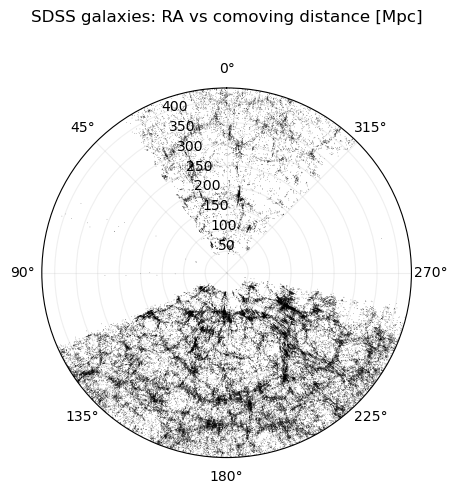

In [23]:
d = comoving_distance.value
slice = (dec > 10) & (dec < 24.4)

ax = plt.subplot(111, projection="polar")
ax.scatter(np.deg2rad(ra[slice]), d[slice], s=0.25, c="k", alpha=0.55, edgecolors="none")
ax.set_theta_zero_location("N")
ax.set_thetamin(0); ax.set_thetamax(360)
ax.set_rmax(430); ax.grid(alpha=0.2)
ax.set_title("SDSS galaxies: RA vs comoving distance [Mpc]\n", pad=16)
plt.savefig("SDSS polar graph.png")
plt.show()